In [12]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
df = pd.read_csv('weight-height.csv')
df.head()

,Gender,Height,Weight
0,Male,73.847017,241.893563
1,Male,68.781904,162.310473
2,Male,74.110105,212.740856
3,Male,71.730978,220.042470
4,Male,69.881796,206.349801


In [13]:
df.shape

(10000, 3)

In [14]:
df['Height'].describe()

count    10000.000000
mean        66.367560
std          3.847528
min         54.263133
25%         63.505620
50%         66.318070
75%         69.174262
max         78.998742
Name: Height, dtype: float64

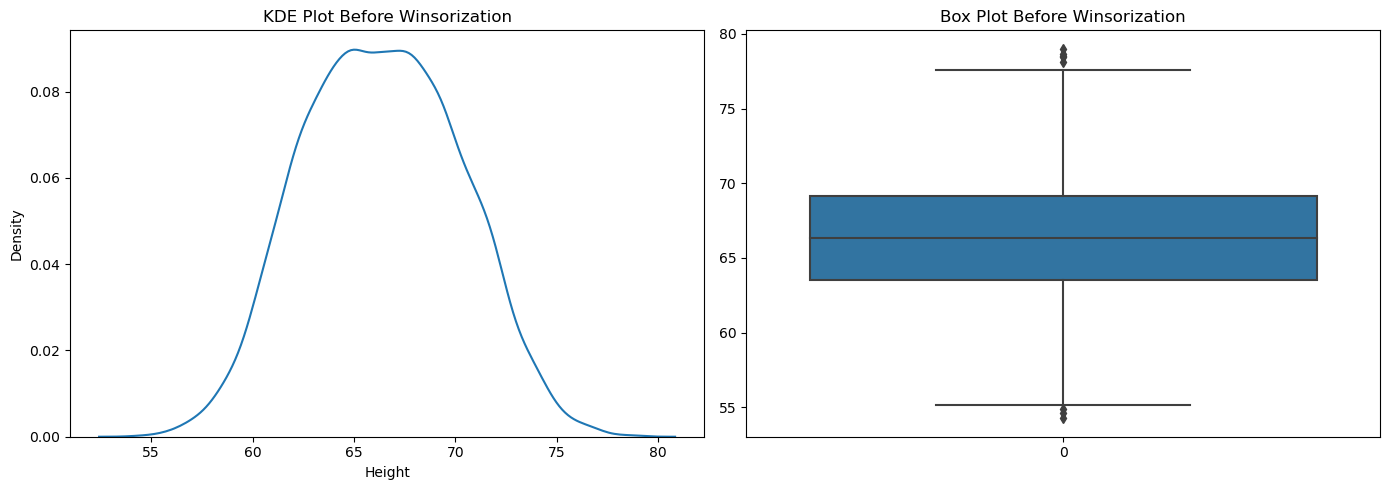

In [15]:

plt.figure(figsize=(14,5))

plt.subplot(1,2,1)
sns.kdeplot(df['Height'])
plt.title('KDE Plot Before Winsorization')

plt.subplot(1,2,2)
sns.boxplot(df['Height'])
plt.title('Box Plot Before Winsorization')

plt.tight_layout()
plt.show()

In [16]:
upper_limit = df['Height'].quantile(0.99)
lower_limit = df['Height'].quantile(0.01)
print("Upper limit",upper_limit)
print("Lower limit",lower_limit)

Upper limit 74.7857900583366
Lower limit 58.13441158671655


In [17]:
new_df = df[(df['Height'] <= upper_limit) & (df['Height'] >= lower_limit)]
new_df['Height'].describe()

count    9800.000000
mean       66.364366
std         3.645075
min        58.134496
25%        63.577162
50%        66.318070
75%        69.119896
max        74.785714
Name: Height, dtype: float64

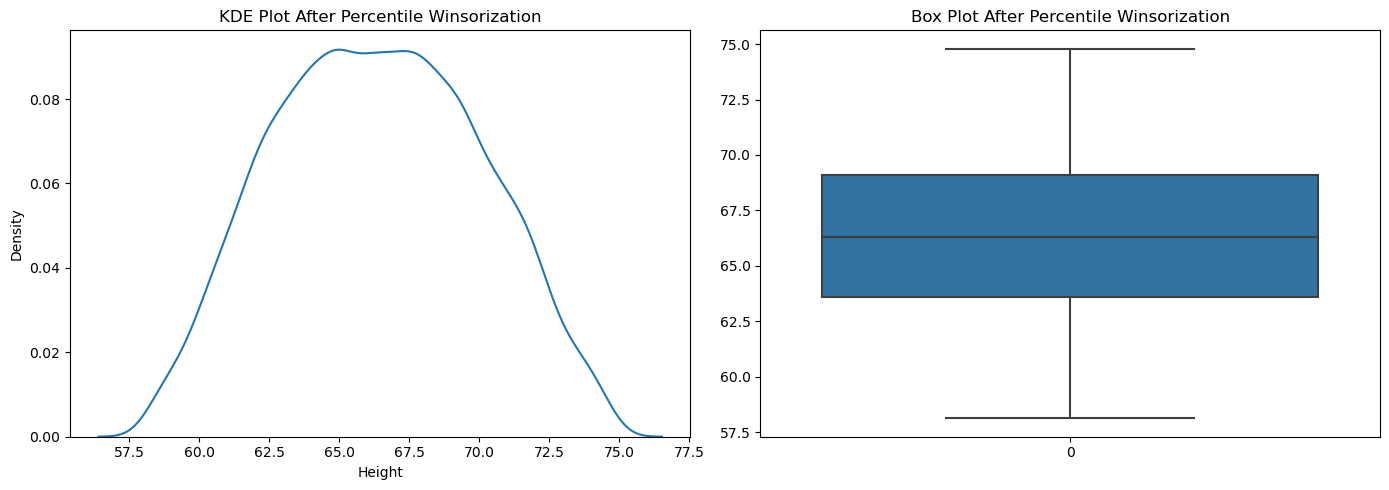

In [18]:
plt.figure(figsize=(14,5))

plt.subplot(1,2,1)
sns.kdeplot(new_df['Height'])
plt.title('KDE Plot After Percentile Winsorization')

plt.subplot(1,2,2)
sns.boxplot(new_df['Height'])
plt.title('Box Plot After Percentile Winsorization')

plt.tight_layout()
plt.show()